# Part 3 — Predictive Modeling: Rider Retention

**Goal:** determine what fraction of the Jan-2014 signup cohort was retained, build a model
predicting whether a rider is still active ~6 months after signup, and translate the drivers
into product recommendations.

**Retention definition:** the data was pulled on **2014-07-01** (the max `last_trip_date` in the
file). A user is "retained" if `last_trip_date` falls in the 30 days before the pull date, i.e.
on or after 2014-06-01.


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

with open('../data/ultimate_data_challenge.json') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(df.shape)
df.head()

(50000, 12)


,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


## 3.1 Cleaning & retention rate

In [2]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])
CUTOFF = pd.Timestamp('2014-07-01')
df['retained'] = (df['last_trip_date'] >= CUTOFF - pd.Timedelta(days=30)).astype(int)

print(f"Retention rate: {df['retained'].mean():.1%}")
df.isna().sum()

Retention rate: 37.6%


city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
retained                     0
dtype: int64

**Missing values:** `phone` (0.8%), `avg_rating_by_driver` (0.4%), and `avg_rating_of_driver`
(16.2%). About half of the missing `avg_rating_of_driver` rows correspond to riders who churned
without ever completing a rated trip; the rest are unexplained by trip count alone, so a
missingness flag is kept as its own feature rather than assuming missing-at-random.

In [3]:
df['rating_of_driver_missing'] = df['avg_rating_of_driver'].isna().astype(int)
df['rating_by_driver_missing'] = df['avg_rating_by_driver'].isna().astype(int)
df['avg_rating_of_driver'] = df['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].median())
df['avg_rating_by_driver'] = df['avg_rating_by_driver'].fillna(df['avg_rating_by_driver'].median())
df['phone'] = df['phone'].fillna('Unknown')
df['ultimate_black_user'] = df['ultimate_black_user'].astype(int)
df['signup_dow'] = df['signup_date'].dt.dayofweek

# avg_dist has a long right tail (max ~161 mi vs 99th pct ~28 mi) - cap it so it doesn't
# dominate the linear model; tree models are unaffected either way.
cap = df['avg_dist'].quantile(0.99)
df['avg_dist_capped'] = df['avg_dist'].clip(upper=cap)
print(f"avg_dist: max={df['avg_dist'].max():.1f}, 99th pct={cap:.1f} -> capped")

avg_dist: max=161.0, 99th pct=27.8 -> capped


## 3.2 A few EDA views before modeling

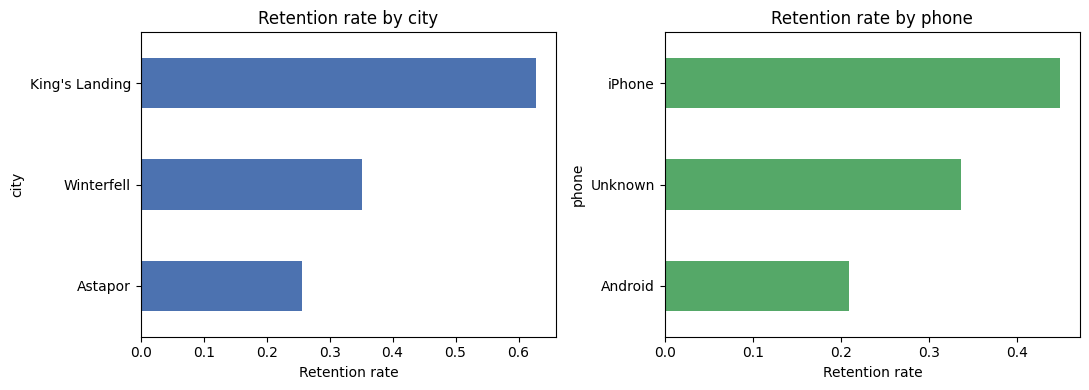

In [4]:
fig, axes = plt.subplots(1,2, figsize=(11,4))
df.groupby('city')['retained'].mean().sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Retention rate by city'); axes[0].set_xlabel('Retention rate')
df.groupby('phone')['retained'].mean().sort_values().plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Retention rate by phone'); axes[1].set_xlabel('Retention rate')
plt.tight_layout()
plt.show()

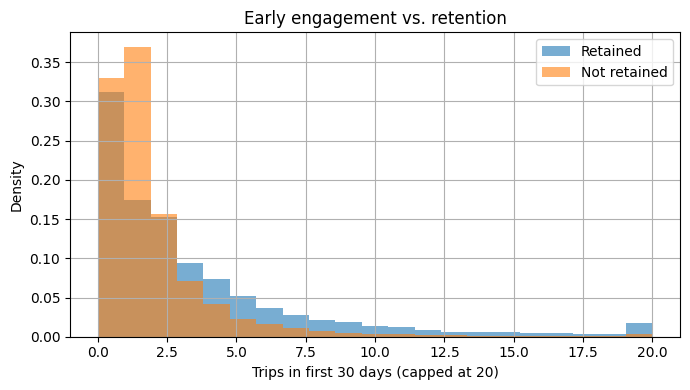

In [5]:
fig, ax = plt.subplots(figsize=(7,4))
df[df['retained']==1]['trips_in_first_30_days'].clip(upper=20).hist(
    bins=21, alpha=0.6, label='Retained', ax=ax, density=True)
df[df['retained']==0]['trips_in_first_30_days'].clip(upper=20).hist(
    bins=21, alpha=0.6, label='Not retained', ax=ax, density=True)
ax.set_xlabel('Trips in first 30 days (capped at 20)'); ax.set_ylabel('Density')
ax.set_title('Early engagement vs. retention'); ax.legend()
plt.tight_layout()
plt.show()

City, phone OS, and early trip volume all show large, roughly monotonic gaps in retention —
good candidate signals. (Full non-linear patterns for `surge_pct` and `weekday_pct` are covered
after modeling, in the feature-importance discussion.)

## 3.3 Model

Three models, in increasing order of flexibility:
- **Logistic regression** — interpretable baseline, needs scaling/encoding.
- **Random forest** — handles non-linearities and interactions natively.
- **Gradient boosting** — usually the strongest of the three on tabular data like this.

`last_trip_date` and `signup_date` themselves are excluded as features (the target is derived
directly from `last_trip_date`, so including it — or close derivatives of it — would leak the
answer).

In [6]:
feature_cols_num = ['trips_in_first_30_days','avg_dist_capped','avg_rating_by_driver',
                     'avg_rating_of_driver','surge_pct','avg_surge','weekday_pct',
                     'ultimate_black_user','rating_of_driver_missing','rating_by_driver_missing',
                     'signup_dow']
feature_cols_cat = ['city','phone']

X = pd.get_dummies(df[feature_cols_num + feature_cols_cat], columns=feature_cols_cat, drop_first=True)
y = df['retained']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(37500, 15) (12500, 15)


In [7]:
results = {}

# Logistic regression (needs scaled inputs)
scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)
logreg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
proba_lr = logreg.predict_proba(X_test_s)[:,1]
pred_lr = logreg.predict(X_test_s)

# Random forest
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                             random_state=42, n_jobs=-1).fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:,1]
pred_rf = rf.predict(X_test)

# Gradient boosting
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                 random_state=42).fit(X_train, y_train)
proba_gb = gb.predict_proba(X_test)[:,1]
pred_gb = gb.predict(X_test)

def score(y_true, pred, proba):
    return dict(acc=accuracy_score(y_true,pred), prec=precision_score(y_true,pred),
                rec=recall_score(y_true,pred), f1=f1_score(y_true,pred),
                auc=roc_auc_score(y_true,proba))

results = pd.DataFrame({
    'LogReg': score(y_test, pred_lr, proba_lr),
    'RandomForest': score(y_test, pred_rf, proba_rf),
    'GradientBoosting': score(y_test, pred_gb, proba_gb),
}).T
results

,acc,prec,rec,f1,auc
LogReg,0.72040,0.671893,0.501383,0.574248,0.761641
RandomForest,0.78232,0.761490,0.613274,0.679392,0.847189
GradientBoosting,0.79168,0.746300,0.675814,0.709310,0.856849


In [8]:
cv_auc = cross_val_score(rf, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"Random forest 5-fold CV AUC: {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")

Random forest 5-fold CV AUC: 0.8456 +/- 0.0036


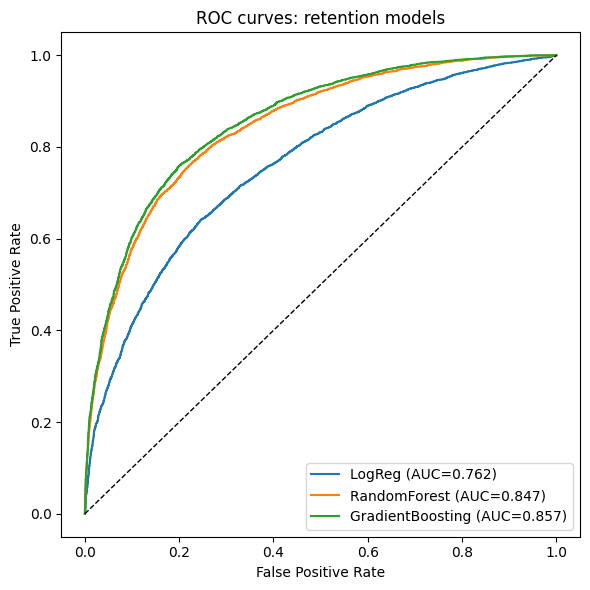

In [9]:
fig, ax = plt.subplots(figsize=(6,6))
for name, proba in [('LogReg',proba_lr), ('RandomForest',proba_rf), ('GradientBoosting',proba_gb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test,proba):.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves: retention models'); ax.legend()
plt.tight_layout()
plt.show()

Gradient boosting is the strongest model (AUC ≈ 0.86) and is the one carried forward. The
5-fold CV AUC (0.846 ± 0.004 for the random forest) is close to the single-split random forest
AUC, so the result is stable and not an artifact of one particular train/test split.

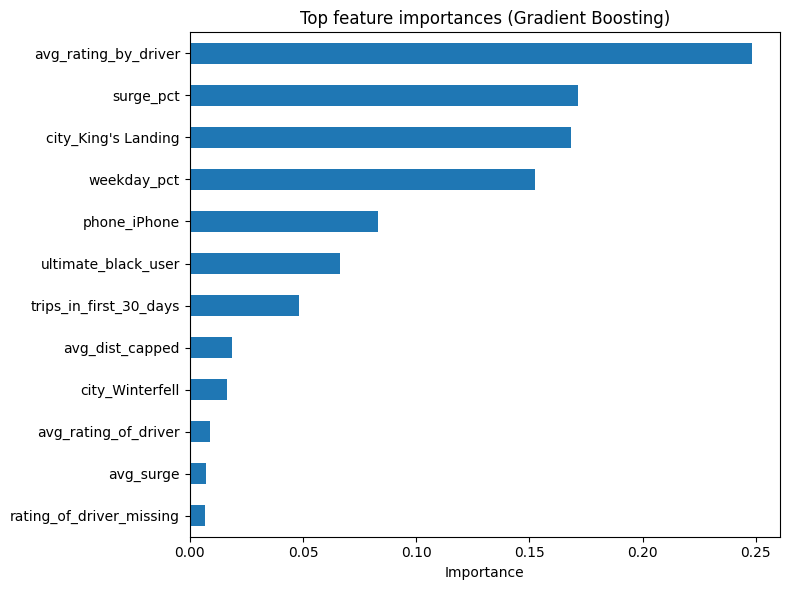

avg_rating_by_driver      0.248238
surge_pct                 0.171375
city_King's Landing       0.168442
weekday_pct               0.152469
phone_iPhone              0.083054
ultimate_black_user       0.066342
trips_in_first_30_days    0.048149
avg_dist_capped           0.018644
dtype: float64

In [10]:
imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
imp.head(12).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top feature importances (Gradient Boosting)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

imp.head(8)

In [11]:
cm = confusion_matrix(y_test, pred_gb)
print("Confusion matrix [rows=actual, cols=predicted]:\n", cm)
print()
print(classification_report(y_test, pred_gb, target_names=['Not retained','Retained']))

Confusion matrix [rows=actual, cols=predicted]:
 [[6719 1080]
 [1524 3177]]

              precision    recall  f1-score   support

Not retained       0.82      0.86      0.84      7799
    Retained       0.75      0.68      0.71      4701

    accuracy                           0.79     12500
   macro avg       0.78      0.77      0.77     12500
weighted avg       0.79      0.79      0.79     12500



## 3.4 Interpreting the drivers

Checking the direction/shape behind the top features (not just their importance rank):

- **`avg_rating_by_driver` (top feature).** How drivers rated the rider — the most important
  single signal, though the raw linear correlation with retention is near zero, meaning the
  relationship is non-linear/threshold-like rather than "higher rating = more retention"
  in a straight line. This is worth a closer look with partial dependence plots before treating
  it as fully causal (it may also proxy for tenure — riders with more trips have had more chances
  to earn ratings that stabilize near their "true" rating).
- **`city`** — retention swings from **63% in King's Landing** to **35% in Winterfell** to
  **26% in Astapor**. This is a large, geography-level gap that likely reflects market maturity,
  local competition, or service quality differences rather than anything about individual riders.
- **`phone`** — iPhone users retain at **45%** vs. **21%** for Android, a striking gap worth
  validating against platform-specific onboarding/app-quality issues.
- **`surge_pct`** — non-monotonic: retention is *highest* (≈81%) for riders with light surge
  exposure (0–10% of trips), and falls off sharply at heavy exposure (≈19% for 50–100% of
  trips). Some surge exposure likely proxies for being a frequent, engaged urban rider; heavy
  surge exposure looks like a genuine price-sensitivity churn driver.
- **`weekday_pct`** — also an inverted-U: riders who mix weekday and weekend usage (50–75%
  weekday) retain best (≈63%), while riders who ride almost exclusively on weekends (≈23%) or
  almost exclusively on weekdays (≈30%) retain worse. Balanced, habitual use looks stickier than
  single-context use.
- **`trips_in_first_30_days`** — a clear positive, roughly linear relationship: early engagement
  in the first month predicts longer-run retention, consistent with an "aha moment"/habit-formation
  story.
